In [1]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from src.data_cleaning import prepare_ABC_results

In [4]:
sns.set_context("paper", font_scale=2)

In [5]:
result_paths = list(Path("outputs/causal4/behavior_decoding").glob("**/results.pt"))
groupby = ["word_end"]

A_results_path = Path("outputs/causal4/unify_As/results.csv")
A_stimulus_decoders_path = Path("outputs/causal4/unify_As/unified_decoders.pt")
B_results_path = Path("outputs/causal4/annotated_B_results.csv")
C_results_path = Path("outputs/causal4/annotated_C_results.csv")

electrodes_paths = list(Path("outputs/causal4/find_speech_responsive").glob("*_results.csv"))

textgrid_dir = "textgrids"

# don't include behavioral decoding results from windows before this point
min_decoding_sample = 40
# don't include behavioral decoding results from windows beyond this point
max_decoding_sample = 290 # ~2.5 seconds post onset
# for A's, keep it an earlier window -- we want to see whether the early acoustic response in
# particular is predictive of behavior
A_max_decoding_sample = 70 # 0.3 seconds post onset
# for B's and C's, don't include the acoustic window
BC_min_decoding_sample = 70

In [6]:
electrode_df = pd.concat([pd.read_csv(path) for path in electrodes_paths]).set_index(["subject", "electrode_idx"])

In [7]:
A_results, B_results, C_results = prepare_ABC_results(A_results_path, B_results_path, C_results_path)

Sites with duplicate effects (17, 11.41%):
subject  electrode_idx  phoneme_pair  roi             
EC243    102            dn            postcentral         2
EC250    207            dn            superiortemporal    2
EC260    68             bm            parsopercularis     2
         217            bm            superiortemporal    2
         230            bm            middletemporal      2
         250            bm            postcentral         2
         239            dn            superiortemporal    2
         233            dn            postcentral         2
EC279    23             dn            superiortemporal    2
         11             pb            supramarginal       2
         29             dn            supramarginal       2
         6              pb            superiortemporal    2
EC287    35             dn            superiortemporal    2
EC260    229            bm            superiortemporal    3
EC243    68             dn            superiortemporal    3
EC

/userdata/jgauthier/projects/barakeet/src/data_cleaning.py:78: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  integration_df[new_col] = integration_df[col].replace({"+": 1, "-": -1, np.nan: 0}).astype(int)
/userdata/jgauthier/projects/barakeet/src/data_cleaning.py:78: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  integration_df[new_col] = integration_df[col].replace({"+": 1, "-": -1, np.nan: 0}).astype(int)
/userdata/jgauthier/projects/barakeet/src/data_cleaning.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy

In [8]:
A_stimulus_decoders = torch.load(A_stimulus_decoders_path)

/tmp/ipykernel_2449152/3569155459.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  A_stimulus_decoders = torch.load(A_stimulus_decoders_path)


In [9]:
# A_decoding_results, B_decoding_results, C_decoding_results, manual_decoding_results = {}, {}, {}, {}
A_decoding_results, A_decoders = {}, {}
B_decoding_results, B_decoders = {}, {}
C_decoding_results, C_decoders = {}, {}
for path in tqdm(result_paths):
    loaded = torch.load(path)
    subject = path.parent.name

    A_decoding_results = {**A_decoding_results, **loaded["A_decoding_results"]}
    B_decoding_results = {**B_decoding_results, **loaded["B_decoding_results"]}
    C_decoding_results = {**C_decoding_results, **loaded["C_decoding_results"]}

    A_decoders = {**A_decoders, **loaded["A_decoders"]}
    B_decoders = {**B_decoders, **loaded["B_decoders"]}
    C_decoders = {**C_decoders, **loaded["C_decoders"]}
    # manual_decoding_results = {**manual_decoding_results, **loaded["manual_decoding_results"]}

  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_2449152/2675491519.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(path)


/tmp/ipykernel_2449152/2675491519.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(path)
/tmp/ipykernel_2449152/2675491519.py:6: FutureWarning: You ar

In [94]:
A_results_df = pd.concat(A_decoding_results, names=["subject", "population_name", "phoneme_pair"], ignore_index=True)
B_results_df = pd.concat(B_decoding_results, names=["subject", "population_name", "phoneme_pair"], ignore_index=True)
C_results_df = pd.concat(C_decoding_results, names=["subject", "population_name", "phoneme_pair"], ignore_index=True)

In [95]:
A_early_results_df = A_results_df[(A_results_df.smin >= min_decoding_sample) & (A_results_df.smax <= A_max_decoding_sample)]
A_results_df = A_results_df[(A_results_df.smin >= A_max_decoding_sample) & (A_results_df.smax <= max_decoding_sample)]
B_results_df = B_results_df[(B_results_df.smin >= BC_min_decoding_sample) & (B_results_df.smax <= max_decoding_sample)]
C_results_df = C_results_df[(C_results_df.smin >= BC_min_decoding_sample) & (C_results_df.smax <= max_decoding_sample)]

In [96]:
A_early_results_df["diff"] = A_early_results_df["full_roc_auc"] - A_early_results_df["baseline_roc_auc"]
A_results_df["diff"] = A_results_df["full_roc_auc"] - A_results_df["baseline_roc_auc"]
B_results_df["diff"] = B_results_df["full_roc_auc"] - B_results_df["baseline_roc_auc"]
C_results_df["diff"] = C_results_df["full_roc_auc"] - C_results_df["baseline_roc_auc"]

In [97]:
A_veridical_summary = A_results_df.query("population == 'veridical'") \
    .groupby(["subject", "population", "phoneme_pair", "smin", "smax"] + groupby) \
    [["baseline_roc_auc", "full_roc_auc", "diff"]].mean()
A_veridical_max_points = A_veridical_summary \
    .groupby(["subject", "population", "phoneme_pair"] + groupby)["diff"].idxmax()
A_veridical_final_summary = A_veridical_summary.loc[A_veridical_max_points]

In [98]:
A_nonveridical_summary = A_results_df.query("population != 'veridical'") \
    .groupby(["subject", "population", "phoneme_pair", "smin", "smax"] + groupby) \
    [["baseline_roc_auc", "full_roc_auc", "diff"]].mean()
A_nonveridical_max_points = A_nonveridical_summary \
    .groupby(["subject", "population", "phoneme_pair"] + groupby)["diff"].idxmax()
A_nonveridical_final_summary = A_nonveridical_summary.loc[A_nonveridical_max_points]

In [99]:
A_early_veridical_summary = A_early_results_df.query("population == 'veridical'") \
    .groupby(["subject", "population", "phoneme_pair", "smin", "smax"] + groupby) \
    [["baseline_roc_auc", "full_roc_auc", "diff"]].mean()
A_early_veridical_max_points = A_early_veridical_summary \
    .groupby(["subject", "population", "phoneme_pair"] + groupby)["diff"].idxmax()
A_early_veridical_final_summary = A_early_veridical_summary.loc[A_early_veridical_max_points]

In [100]:
A_early_nonveridical_summary = A_early_results_df.query("population != 'veridical'") \
    .groupby(["subject", "population", "phoneme_pair", "smin", "smax"] + groupby) \
    [["baseline_roc_auc", "full_roc_auc", "diff"]].mean()
A_early_nonveridical_max_points = A_early_nonveridical_summary \
    .groupby(["subject", "population", "phoneme_pair"] + groupby)["diff"].idxmax()
A_early_nonveridical_final_summary = A_early_nonveridical_summary.loc[A_early_nonveridical_max_points]

In [54]:
B_summary = B_results_df.groupby(["subject", "population", "phoneme_pair", "smin", "smax"] + groupby)[["baseline_roc_auc", "full_roc_auc", "diff"]].mean()
B_max_points = B_summary.groupby(["subject", "population", "phoneme_pair"] + groupby)["diff"].idxmax()
B_final_summary = B_summary.loc[B_max_points]
# B_final_summary.sort_values("diff")

In [55]:
B_final_summary["roi"] = B_final_summary.index.get_level_values("population").str.split("-").str[0]
B_final_summary["temporal pattern"] = B_final_summary.index.get_level_values("population").str.split("-").str[1]

In [56]:
C_summary = C_results_df.groupby(["subject", "population", "phoneme_pair", "smin", "smax"] + groupby)[["baseline_roc_auc", "full_roc_auc", "diff"]].mean()
C_max_points = C_summary.groupby(["subject", "population", "phoneme_pair"] + groupby)["diff"].idxmax()
C_final_summary = C_summary.loc[C_max_points]
C_final_summary["temporal pattern"] = C_final_summary.index.get_level_values("population")
# C_final_summary.sort_values("diff")

In [57]:
words = {
    "bm": ["bountiful", "mountains"],
    "dn": ["desolate", "necessary"],
    "pb": ["penecillin", "beneficial"],
}
def get_active_words(rows):
    active_words = []
    if (rows.left_polarity != 0).any():
        active_words.append(words[rows.phoneme_pair.iloc[0]][0])
    if (rows.right_polarity != 0).any():
        active_words.append(words[rows.phoneme_pair.iloc[0]][1])
    return pd.Series(active_words).rename("word_end")

active_B_words = B_results.groupby(["subject", "population_name", "phoneme_pair", "Temporal pattern"]).apply(get_active_words).reset_index()
active_B_words["population"] = active_B_words["population_name"] + "-" + active_B_words["Temporal pattern"]

# Only keep decoding results on the subset of words for which we saw meaningful B responses
B_final_summary = pd.merge(active_B_words, B_final_summary.reset_index(),
                           on=["subject", "population", "phoneme_pair", "word_end"], how="inner")
B_final_summary = B_final_summary.set_index(["subject", "population", "phoneme_pair", "smin", "smax", "word_end"])

/tmp/ipykernel_2449152/1614907478.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  active_B_words = B_results.groupby(["subject", "population_name", "phoneme_pair", "Temporal pattern"]).apply(get_active_words).reset_index()


In [58]:
active_C_words = C_results.groupby(["subject", "Temporal pattern", "phoneme_pair"]).apply(get_active_words) \
    .reset_index().rename(columns={"Temporal pattern": "population"})
C_final_summary = pd.merge(active_C_words, C_final_summary.reset_index(),
                           on=["subject", "population", "phoneme_pair", "word_end"], how="inner")
C_final_summary = C_final_summary.set_index(["subject", "population", "phoneme_pair", "smin", "smax", "word_end"])

/tmp/ipykernel_2449152/3630636515.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  active_C_words = C_results.groupby(["subject", "Temporal pattern", "phoneme_pair"]).apply(get_active_words) \


In [101]:
all_summary = pd.concat({"A_veridical": A_veridical_final_summary,
                         "A_nonveridical": A_nonveridical_final_summary,
                            "A_early_veridical": A_early_veridical_final_summary,
                            "A_early_nonveridical": A_early_nonveridical_final_summary,
                         "B": B_final_summary, "C": C_final_summary,
                         },
                        names=["source"]).reset_index()

In [102]:
# g = sns.displot(all_summary, x="baseline_roc_auc", col="source", hue="phoneme_pair", height=3, aspect=2)
# g.set_axis_labels("Baseline ROC-AUC", "Count")

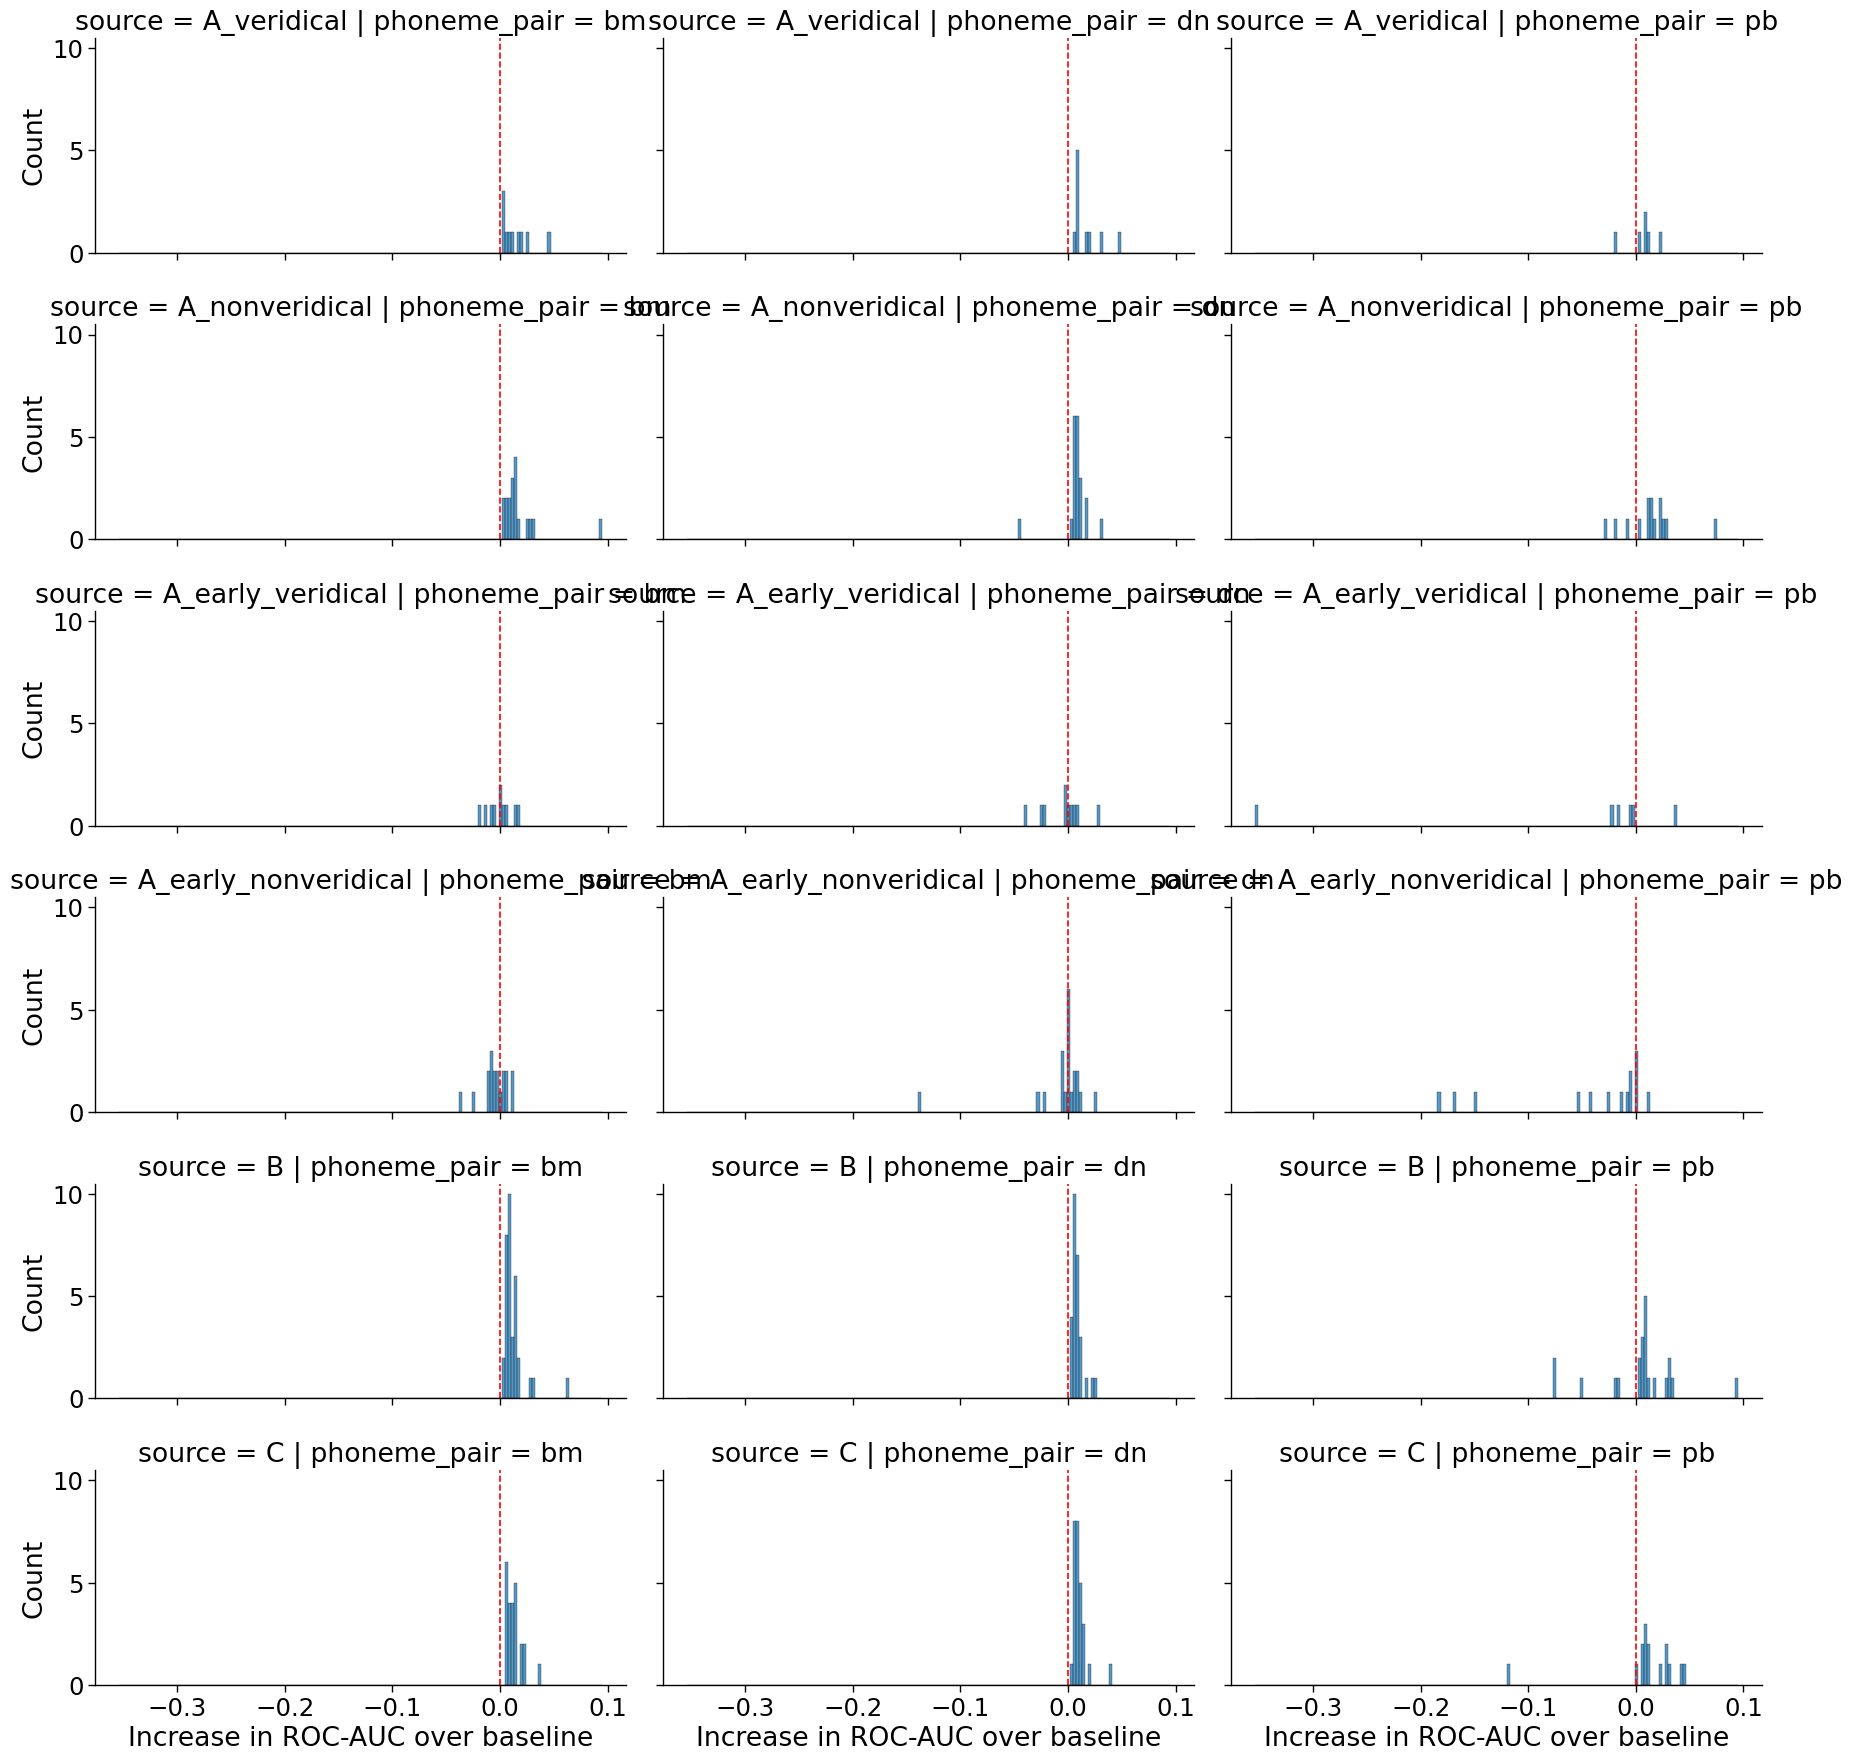

In [103]:
g = sns.displot(all_summary, x="diff", row="source", col="phoneme_pair", height=3, aspect=2)
g.set_axis_labels("Increase in ROC-AUC over baseline", "Count")
for ax in g.axes.flat:
    ax.axvline(0, color="red", linestyle="--")

## Basic quant tests

In [62]:
from scipy.stats import ttest_rel

In [104]:
ttest_rel(A_veridical_final_summary.baseline_roc_auc, A_veridical_final_summary.full_roc_auc)

TtestResult(statistic=-5.043761501549812, pvalue=3.328240633263737e-05, df=25)

In [105]:
ttest_rel(A_nonveridical_final_summary.baseline_roc_auc, A_nonveridical_final_summary.full_roc_auc)

TtestResult(statistic=-4.739208555126412, pvalue=1.7582339217100988e-05, df=51)

In [106]:
ttest_rel(A_early_veridical_final_summary.baseline_roc_auc, A_early_veridical_final_summary.full_roc_auc)

TtestResult(statistic=1.1492571773476694, pvalue=0.26132662980254623, df=25)

In [107]:
ttest_rel(A_early_nonveridical_final_summary.baseline_roc_auc, A_early_nonveridical_final_summary.full_roc_auc)

TtestResult(statistic=2.655331262537996, pvalue=0.010545197682669906, df=51)

In [108]:
ttest_rel(B_final_summary.baseline_roc_auc, B_final_summary.full_roc_auc)

TtestResult(statistic=-3.964784406111606, pvalue=0.0001562639751096521, df=82)

In [109]:
ttest_rel(C_final_summary.baseline_roc_auc, C_final_summary.full_roc_auc)

TtestResult(statistic=-4.889008894001083, pvalue=6.964402339229307e-06, df=65)

## Inspect As

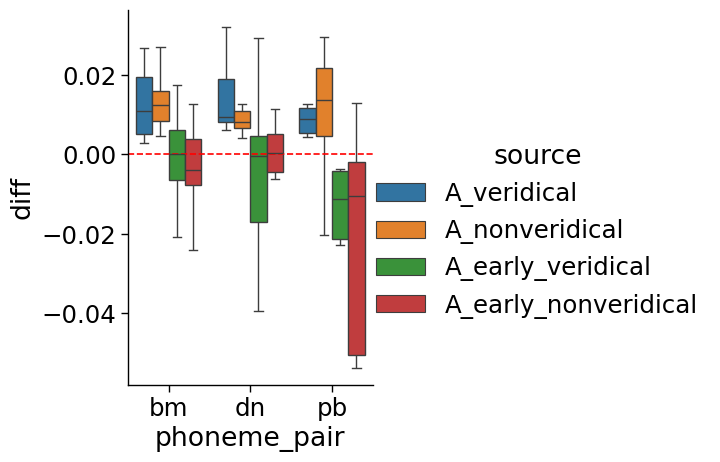

In [112]:
g = sns.catplot(data=all_summary[all_summary.source.str.startswith("A")],
                x="phoneme_pair", hue="source", y="diff", kind="box", showfliers=False)
g.ax.axhline(0, color="red", linestyle="--")

## Inspect Bs

In [29]:
# # g = sns.displot(data=B_final_summary, x="diff", row="temporal pattern", col="phoneme_pair", height=3, aspect=2)
# # g.set_axis_labels("Increase in ROC-AUC over baseline", "Count")
# # for ax in g.axes.flat:
# #     ax.axvline(0, color="red", linestyle="--")
# g = sns.catplot(data=manual_final_summary, x="population", y="diff", col="phoneme_pair", kind="box")
# for ax in g.axes.flat:
#     ax.axhline(0, color="red", linestyle="--")

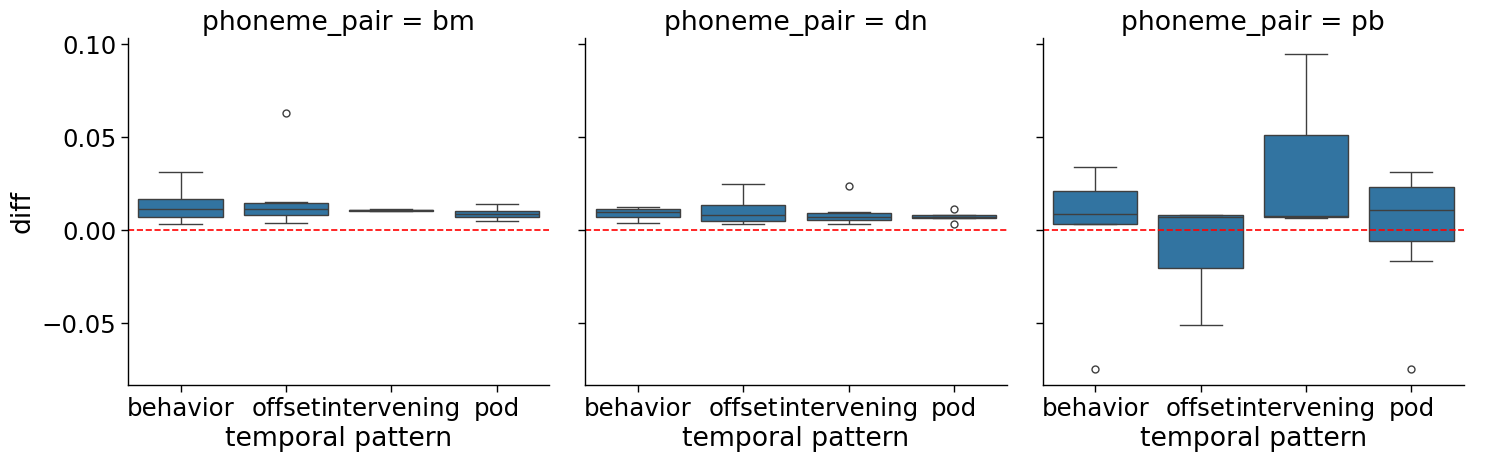

In [30]:
# g = sns.displot(data=B_final_summary, x="diff", row="temporal pattern", col="phoneme_pair", height=3, aspect=2)
# g.set_axis_labels("Increase in ROC-AUC over baseline", "Count")
# for ax in g.axes.flat:
#     ax.axvline(0, color="red", linestyle="--")
g = sns.catplot(data=B_final_summary, x="temporal pattern", y="diff", col="phoneme_pair", kind="box")
for ax in g.axes.flat:
    ax.axhline(0, color="red", linestyle="--")

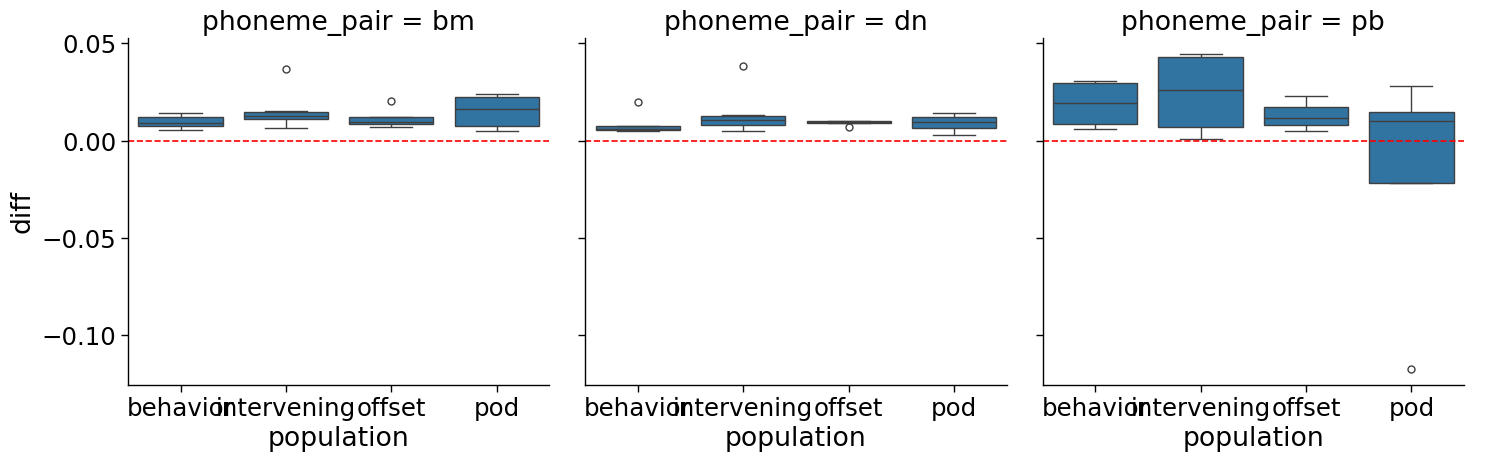

In [127]:
# g = sns.displot(data=B_final_summary, x="diff", row="temporal pattern", col="phoneme_pair", height=3, aspect=2)
# g.set_axis_labels("Increase in ROC-AUC over baseline", "Count")
# for ax in g.axes.flat:
#     ax.axvline(0, color="red", linestyle="--")
g = sns.catplot(data=C_final_summary, x="population", y="diff", col="phoneme_pair", kind="box")
for ax in g.axes.flat:
    ax.axhline(0, color="red", linestyle="--")

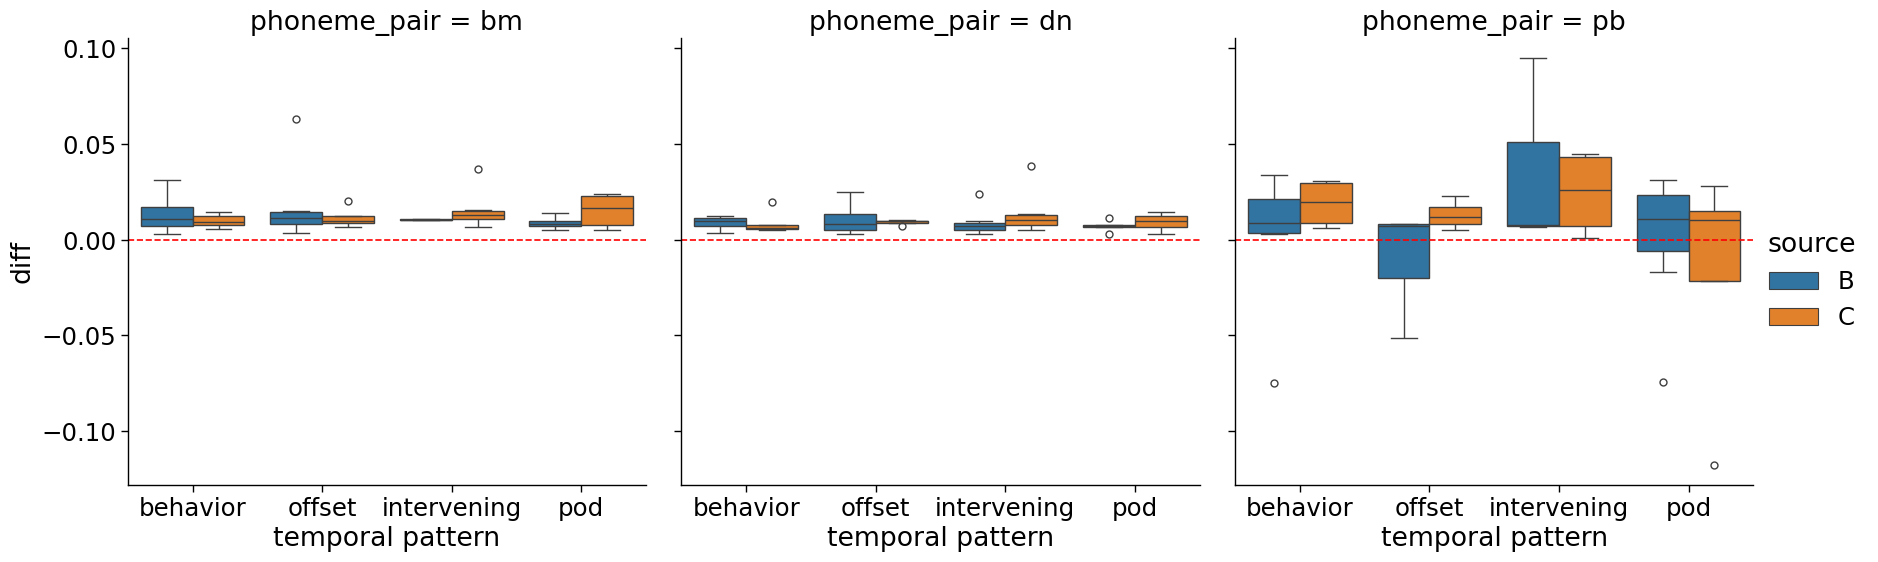

In [159]:
g = sns.catplot(data=all_summary[all_summary.source.isin(("B", "C"))],
                x="temporal pattern", y="diff", col="phoneme_pair", hue="source",
                kind="box", height=6, aspect=1)
for ax in g.axes.flat:
    ax.axhline(0, color="red", linestyle="--")

In [71]:
def spaghetti_plot(df, x="source", **catplot_kwargs):
    # spaghetti plot of baseline_roc_auc -> full_roc_auc

    melted = df.melt(
        id_vars=list(set([x] + ["subject", "population", "phoneme_pair", "smin", "smax", "word_end"])),
        value_vars=["baseline_roc_auc", "full_roc_auc"]
    )
    
    catplot_kwargs = {
        "jitter": 0.05,
        "s": 20,
        "height": 5,
        "aspect": 0.7,
        **catplot_kwargs
    }
    g = sns.catplot(
        data=melted,
        hue="variable", y="value", x=x, col="phoneme_pair",
        kind="strip", dodge=True,
        **catplot_kwargs
    )
    g.set_axis_labels("Population kind", "Behavior decoding\nROC-AUC")
    g.set_titles(col_template="Phoneme pair:\n{col_name}")

    ## Overlay spaghetti lines

    # Small manual horizontal offset to match the two hue positions
    offset = 0.20   # tweak if your hue dodge looks slightly different

    # For each facet, draw lines between baseline/full at each source tick, per subject
    for (row_key, ax) in g.axes_dict.items():
        # When only row faceting, axes_dict keys are the row values themselves
        # (If your seaborn version returns tuples, handle accordingly)
        row_val = row_key if not isinstance(row_key, tuple) else row_key[0]

        data_f = melted[melted["phoneme_pair"] == row_val].copy()

        # Get x positions for each 'source' category on this axis
        xlabels = [t.get_text() for t in ax.get_xticklabels()]
        xticks = ax.get_xticks()
        xmap = dict(zip(xlabels, xticks))

        # group by source and subject (add other keys if needed to disambiguate)
        for (src, subj, pop, word_end), d in data_f.groupby([x] + ["subject", "population", "word_end"], sort=False):
            assert len(d) == 2
            assert d["variable"].nunique() == 2

            # Pull the two y-values
            try:
                y_base = d.loc[d["variable"] == "baseline_roc_auc", "value"].iloc[0]
                y_full = d.loc[d["variable"] == "full_roc_auc", "value"].iloc[0]
            except IndexError:
                continue

            x0 = xmap.get(src, None)
            if x0 is None:
                continue

            # Draw the connecting line (thin, slightly transparent)
            style = ["solid", "dashed"][words[d.phoneme_pair.iloc[0]].index(d.word_end.iloc[0])]
            ax.plot(
                [x0 - offset, x0 + offset],
                [y_base, y_full],
                lw=0.7, alpha=0.35, color="gray", zorder=0, clip_on=False,
                linestyle=style
            )
            

    # Optional: bring points above lines & tidy
    for ax in g.axes.flat:
        for c in ax.collections:
            c.set_zorder(2)

    g.legend.remove()
    g.add_legend(title="Evaluation", labels=["Baseline", "Full model"])

    return g

/tmp/ipykernel_2449152/3040639646.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/tmp/ipykernel_2449152/3040639646.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/tmp/ipykernel_2449152/3040639646.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


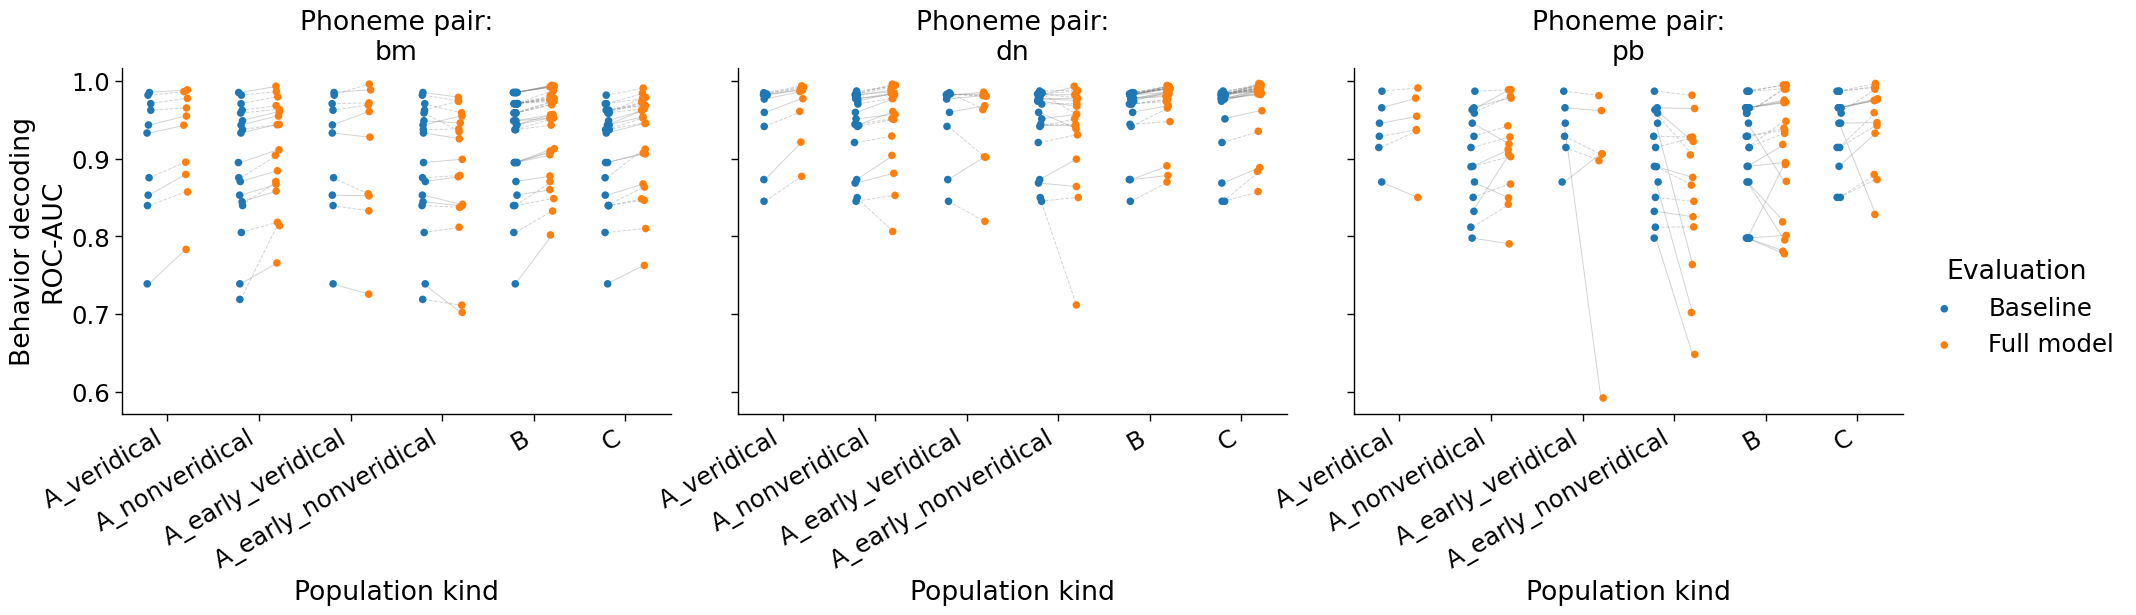

In [113]:
g = spaghetti_plot(all_summary, aspect=1.1, s=30)
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

/tmp/ipykernel_2449152/13025441.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/tmp/ipykernel_2449152/13025441.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/tmp/ipykernel_2449152/13025441.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


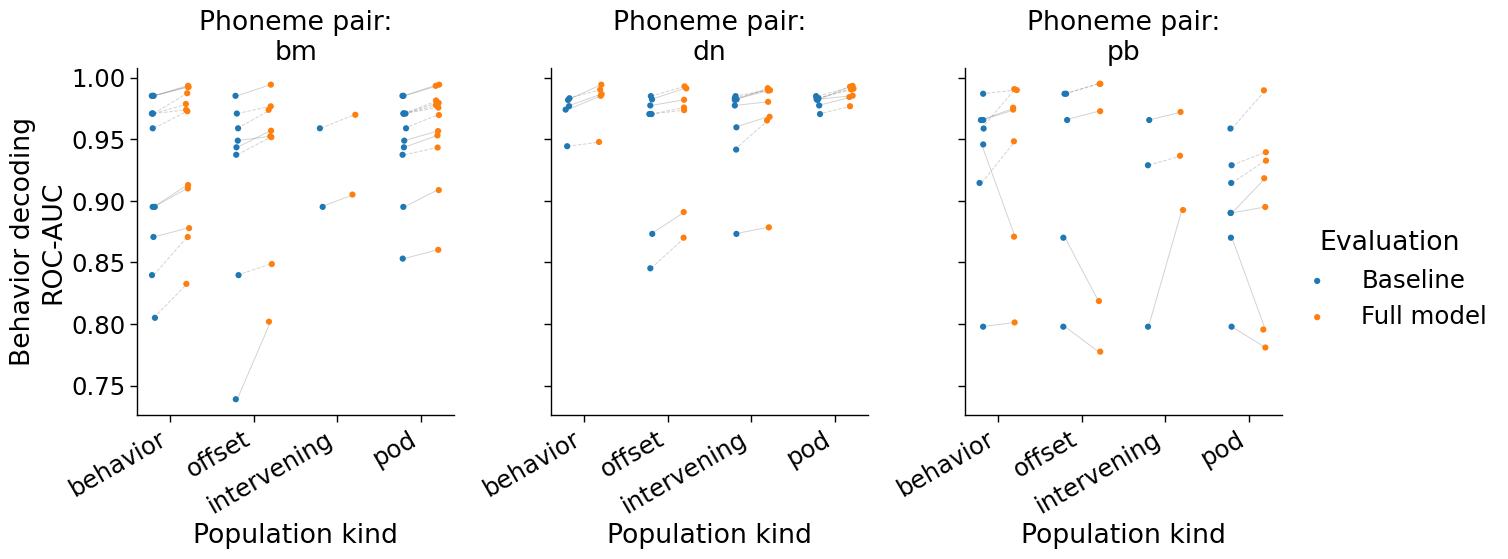

In [73]:
g = spaghetti_plot(B_final_summary.reset_index(), x="temporal pattern")
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

/tmp/ipykernel_2449152/939884030.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_2449152/939884030.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_2449152/939884030.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


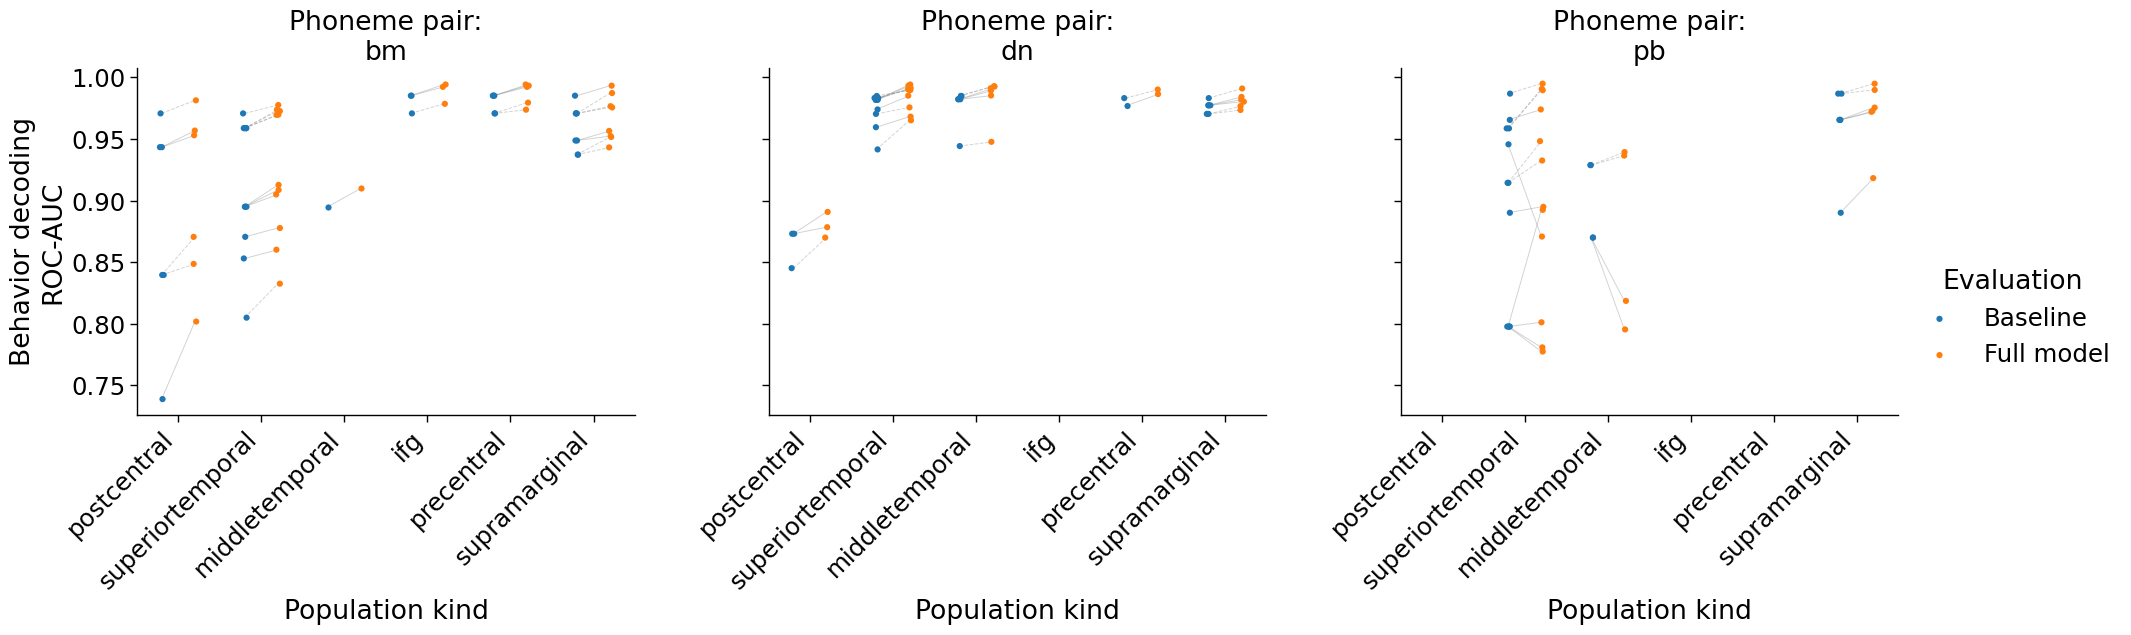

In [74]:
g = spaghetti_plot(B_final_summary.reset_index(), x="roi", aspect=1.1)
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

/tmp/ipykernel_107702/3510353320.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/tmp/ipykernel_107702/3510353320.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/tmp/ipykernel_107702/3510353320.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


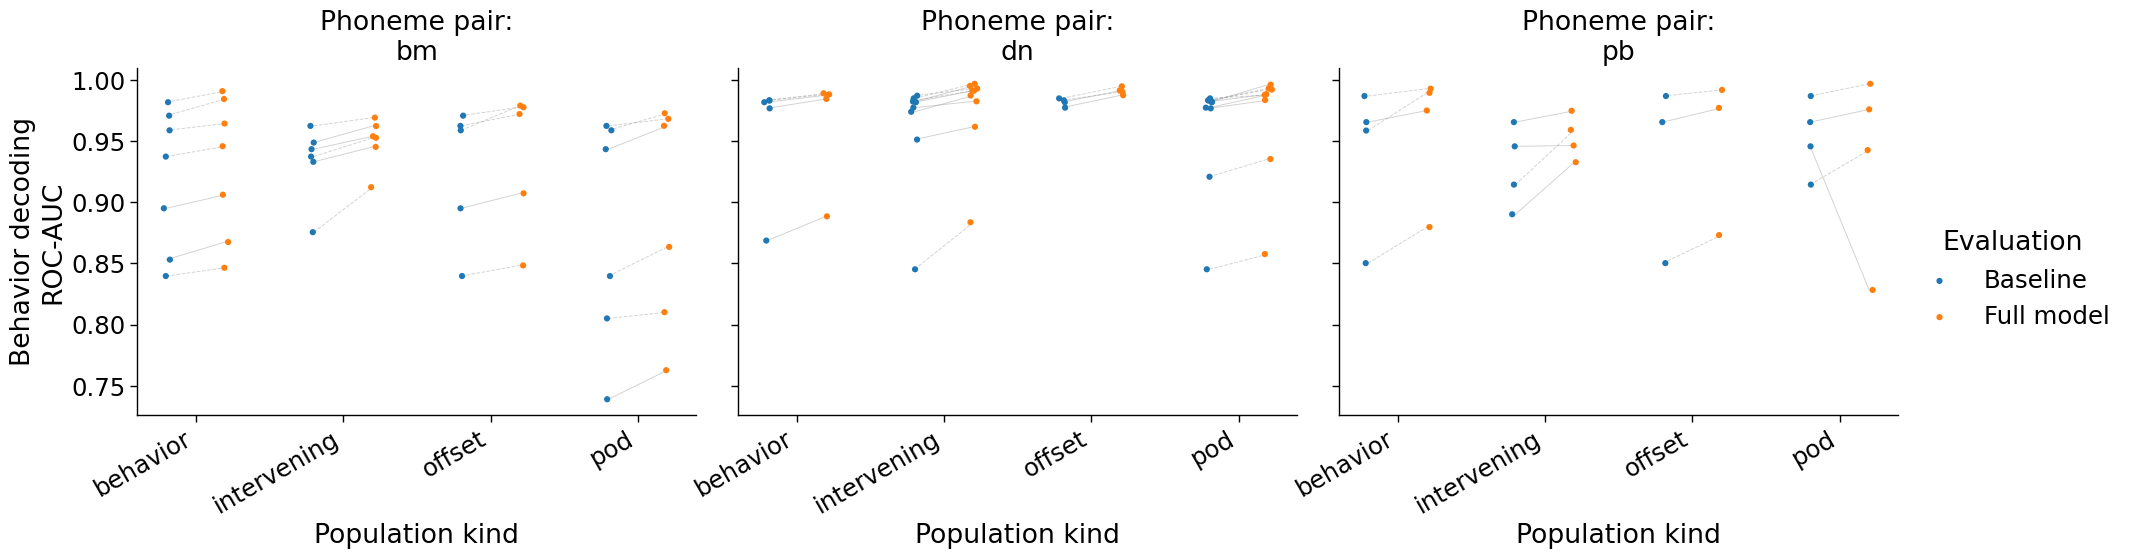

In [133]:
g = spaghetti_plot(C_final_summary.reset_index(), x="population", aspect=1.1)
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

### A timecourse

<Axes: xlabel='tmax', ylabel='diff'>

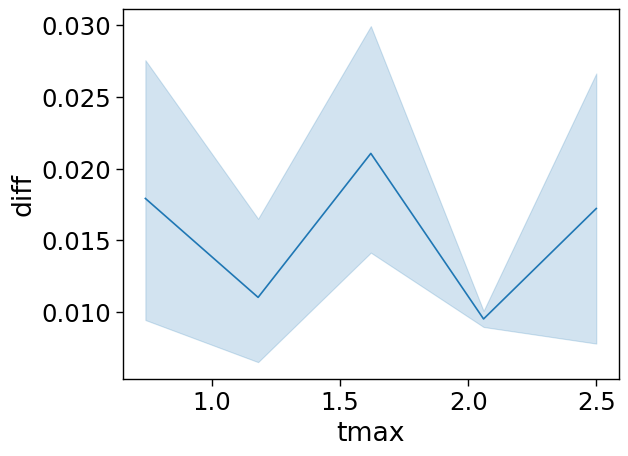

In [75]:
A_veridical_final_summary["smax_bin"] = pd.cut(A_veridical_final_summary.index.get_level_values("smax"), bins=5)
A_veridical_final_summary["smax_bin_edge"] = A_veridical_final_summary["smax_bin"].apply(lambda x: x.right).astype(float)
A_veridical_final_summary["tmax"] = A_veridical_final_summary["smax_bin_edge"] / 100 - 0.4
sns.lineplot(data=A_veridical_final_summary.reset_index(), x="tmax", y="diff")

<Axes: xlabel='tmax', ylabel='diff'>

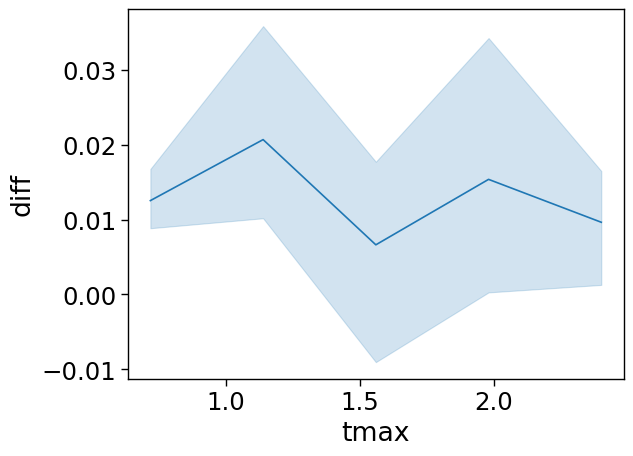

In [76]:
A_nonveridical_final_summary["smax_bin"] = pd.cut(A_nonveridical_final_summary.index.get_level_values("smax"), bins=5)
A_nonveridical_final_summary["smax_bin_edge"] = A_nonveridical_final_summary["smax_bin"].apply(lambda x: x.right).astype(float)
A_nonveridical_final_summary["tmax"] = A_nonveridical_final_summary["smax_bin_edge"] / 100 - 0.4
sns.lineplot(data=A_nonveridical_final_summary.reset_index(), x="tmax", y="diff")

### B timecourse

<Axes: xlabel='tmax', ylabel='diff'>

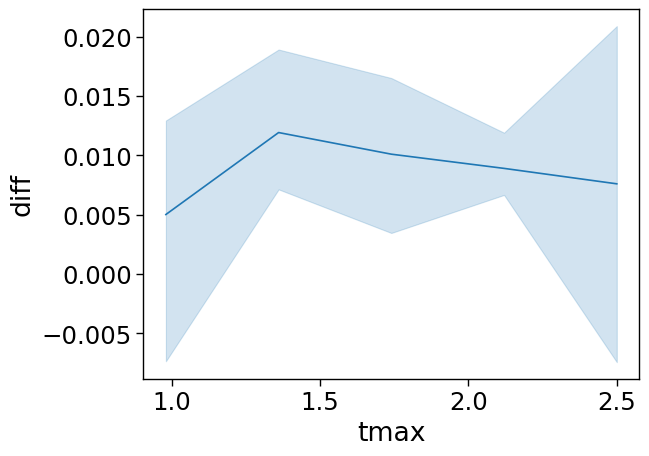

In [134]:
B_final_summary["smax_bin"] = pd.cut(B_final_summary.index.get_level_values("smax"), bins=5)
B_final_summary["smax_bin_edge"] = B_final_summary["smax_bin"].apply(lambda x: x.right).astype(float)
B_final_summary["tmax"] = B_final_summary["smax_bin_edge"] / 100 - 0.4
sns.lineplot(data=B_final_summary.reset_index(), x="tmax", y="diff")

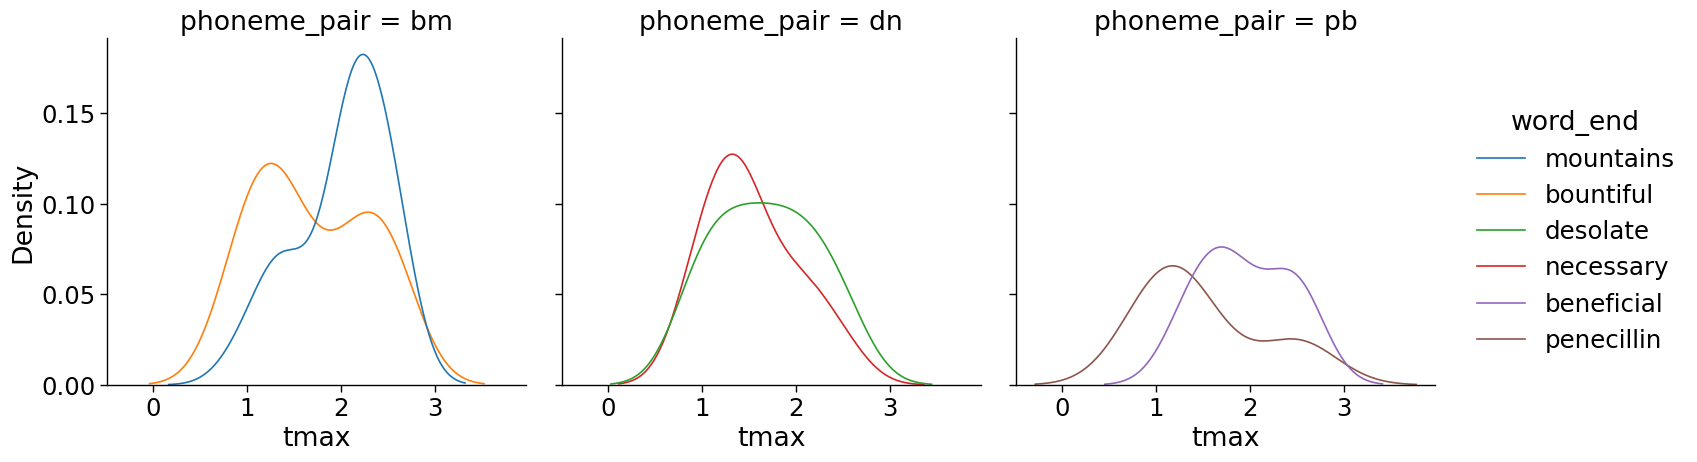

In [135]:
sns.displot(data=B_final_summary.query("diff > 1e-3"), x="tmax", kind="kde", col="phoneme_pair", hue="word_end")

### C timecourse

<Axes: xlabel='tmax', ylabel='diff'>

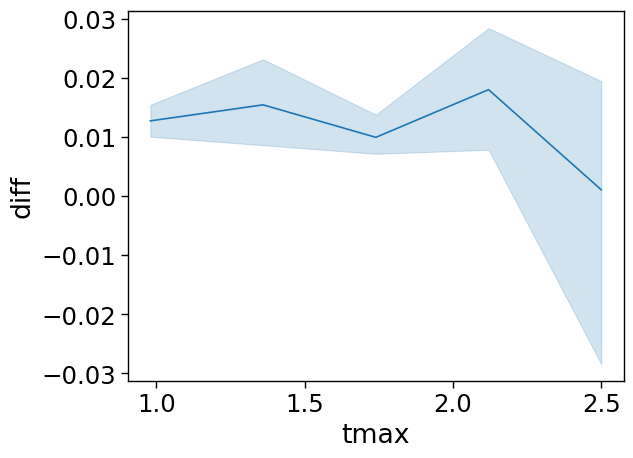

In [136]:
C_final_summary["smax_bin"] = pd.cut(C_final_summary.index.get_level_values("smax"), bins=5)
C_final_summary["smax_bin_edge"] = C_final_summary["smax_bin"].apply(lambda x: x.right).astype(float)
C_final_summary["tmax"] = C_final_summary["smax_bin_edge"] / 100 - 0.4
sns.lineplot(data=C_final_summary.reset_index(), x="tmax", y="diff")

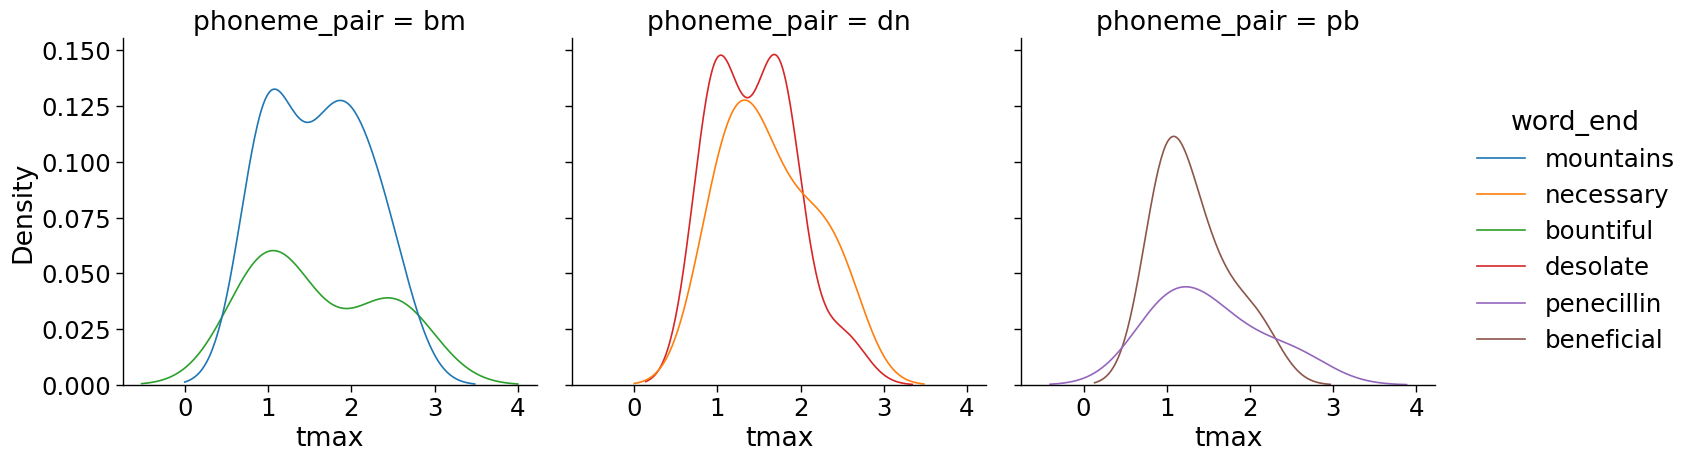

In [137]:
sns.displot(data=C_final_summary.query("diff > 1e-3"), x="tmax", kind="kde", col="phoneme_pair", hue="word_end")

## Visualize decoder weights

In [78]:
from src.models.causal4 import plot_causal4_evoked, Causal4Plotter

In [79]:
import mne
import re
from src.data import add_metadata_features

epochs_paths = list(Path("outputs/epochs_preprocessed").glob("*.fif"))
epochs = {
    re.search(r"(\w+)_epo.fif", str(path)).group(1): mne.read_epochs(path, preload=True, verbose=False)
    for path in tqdm(epochs_paths)
}

  0%|          | 0/10 [00:00<?, ?it/s]

In [80]:
for e in epochs.values():
    e.metadata = add_metadata_features(e.metadata)

Replacing existing metadata with 104 columns
Replacing existing metadata with 104 columns
Replacing existing metadata with 105 columns
Replacing existing metadata with 104 columns
Replacing existing metadata with 104 columns
Replacing existing metadata with 104 columns
Replacing existing metadata with 104 columns
Replacing existing metadata with 104 columns
Replacing existing metadata with 104 columns
Replacing existing metadata with 104 columns


In [81]:
plotter = Causal4Plotter(epochs, A_results, B_results,
                         A_stimulus_decoders, electrode_df,
                         textgrid_dir=textgrid_dir,
                         timit_epoch_sources={})

  0%|          | 0/10 [00:00<?, ?it/s]

In [82]:
from matplotlib.backends.backend_pdf import PdfPages

In [139]:
doc = PdfPages("behavior_decoding_examples.pdf")

In [140]:
def add_title(doc, title):
    fig, ax = plt.subplots(figsize=(8, 1))
    ax.text(0.5, 0.5, title, ha="center", va="center", fontsize=20)
    ax.axis("off")
    doc.savefig(fig)
    plt.close(fig)

In [141]:
def get_behavioral_coefs(estimators, num_electrodes):
    resampled_coefs, electrode_coefs = [], []
    for fold, estimator_i in enumerate(estimators):
        pca = estimator_i.best_estimator_.named_steps["prep"].named_transformers_["pca"].named_steps["pca"]
        logreg = estimator_i.best_estimator_.named_steps["clf"]

        coef_i = logreg.coef_.squeeze()
        resampled_coef_i = coef_i[0]
        pca_coefs_i = coef_i[1:]

        electrode_coefs_i = pca.inverse_transform(pca_coefs_i).squeeze()
        electrode_coefs_split_i = np.split(electrode_coefs_i, num_electrodes)

        resampled_coefs.append(resampled_coef_i)
        electrode_coefs.append(electrode_coefs_split_i)

    electrode_coefs = np.array(electrode_coefs)  # (n_folds, n_electrodes, n_times)

    return resampled_coefs, electrode_coefs

### Viz A decoders

In [142]:
# Prepare map from A electrode idx to A population name
A_electrode_idx_to_population = {}
for (subject, population, phoneme_pair), electrode_idxs in A_stimulus_decoders["populations"].items():
    for electrode_idx in electrode_idxs:
        A_electrode_idx_to_population[(subject, electrode_idx, phoneme_pair)] = population

In [143]:
def viz_A_decoder_weights(study_A: pd.Series,
                          rescale_evoked_to_B_window=True,
                          bin_by_A_population=False,
                          evoked_kwargs=None):
    study_A = study_A.copy()
    veridical = True if study_A.population == "veridical" else False

    decoder_key = (study_A.subject, study_A.phoneme_pair, veridical)
    num_folds = max(fold for _, _, _, _, _, _, fold in A_decoders[decoder_key].keys())

    study_dict = A_decoders[decoder_key][study_A.subject, study_A.population, study_A.phoneme_pair, (study_A.word_end,), study_A.smin, study_A.smax, 0]
    study_electrode_idxs = study_dict["electrode_idxs"]
    study_estimators = [
        A_decoders[decoder_key][study_A.subject, study_A.population, study_A.phoneme_pair, (study_A.word_end,), study_A.smin, study_A.smax, fold]["estimator"]
        for fold in range(num_folds)
    ]

    resampled_coefs, electrode_coefs = get_behavioral_coefs(study_estimators, len(study_electrode_idxs))
    epochs_i = epochs[study_A.subject]

    gs = []
    for i, study_electrode_idx in enumerate(tqdm(study_electrode_idxs)):
        study_A["electrode_idx"] = study_electrode_idx

        # DEV
        study_A["left_is_best"] = False

        if bin_by_A_population:
            population = A_electrode_idx_to_population.get((study_A.subject, study_electrode_idx, study_A.phoneme_pair), None)
            if population is None:
                print(f"Skipping {study_A.subject} electrode {study_electrode_idx} -- not in any A population")
                continue
            study_A["population_name"] = population

        plot_meta_df = plotter._prepare_plot_meta_df(study_A)
        # just keep the relevant word
        plot_meta_df = plot_meta_df[plot_meta_df.word_end == study_A.word_end]
        g = plot_causal4_evoked(epochs_i, plot_meta_df, study_A.subject,
                                (0, 0), (study_A.smin, study_A.smax),
                                **(evoked_kwargs or {}))

        behavior_coefs = electrode_coefs[:, i]
        
        assert len(g.axes.flat) == 1
        ax = g.axes.flat[0]
        if rescale_evoked_to_B_window:
            evoked_data = epochs_i[plot_meta_df.epoch_idx].get_data()[:, study_electrode_idx, study_A.smin:study_A.smax]
            ax.set_ylim(*np.percentile(evoked_data, [10, 90]))

        twinx = ax.twinx()
        plot_samples = np.linspace(study_A.smin, study_A.smax, behavior_coefs.shape[-1], endpoint=False)
        assert np.allclose(plot_samples.astype(int), plot_samples)
        plot_times = epochs_i.times[plot_samples.astype(int)]
        twinx.plot(plot_times, behavior_coefs.mean(0), color="green", label="Behavior decoder", linewidth=2)

        twinx.fill_between(plot_times,
                        np.percentile(behavior_coefs, 25, axis=0),
                        np.percentile(behavior_coefs, 75, axis=0),
                        color="green", alpha=0.3)

        xmax = max(0.75, epochs_i.times[study_A.smax] + 0.1)
        ax.set_xlim(ax.get_xlim()[0], xmax)

        gs.append(g)

    return gs

In [144]:
for label, results_df, plot_by_A in [("A_veridical", A_veridical_final_summary, True),
                          ("A_nonveridical", A_nonveridical_final_summary, True),
                          ("A_early_veridical", A_early_veridical_final_summary, False),
                          ("A_early_nonveridical", A_early_nonveridical_final_summary, False),]:
    print(label)
    add_title(doc, f"Study {label.replace('_', ' ').title()}")

    results_df = results_df.sort_values("diff", ascending=False).query("diff > 1e-2").reset_index()
    for _, study_A in tqdm(results_df.iterrows(), total=len(results_df), leave=False):
        add_title(doc, f"Subject {study_A.subject}, Population {study_A.population}\nPhoneme pair {study_A.phoneme_pair}, Word end {study_A.word_end}")

        evoked_kwargs = dict(height=5)
        if not plot_by_A:
            evoked_kwargs["hue"] = "resampled"
        gs = viz_A_decoder_weights(study_A, evoked_kwargs=evoked_kwargs, bin_by_A_population=plot_by_A)
        for g in gs:
            doc.savefig(g.fig)
            plt.close(g.fig)

A_veridical


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

### Viz B decoders

In [145]:
def viz_decoder_weights(study_B: pd.Series,
                        rescale_evoked_to_B_window=True,
                        evoked_kwargs=None,
                        decoder_dict=None):
    study_B = study_B.copy()

    if decoder_dict is None:
        decoder_dict = B_decoders

    num_folds = max(fold for _, _, _, _, _, _, fold in decoder_dict[study_B.subject, study_B.population, study_B.phoneme_pair].keys())

    study_dict = decoder_dict[study_B.subject, study_B.population, study_B.phoneme_pair][study_B.subject, study_B.population, study_B.phoneme_pair, (study_B.word_end,), study_B.smin, study_B.smax, 0]
    study_electrode_idxs = study_dict["electrode_idxs"]
    study_estimators = [
        decoder_dict[study_B.subject, study_B.population, study_B.phoneme_pair][study_B.subject, study_B.population, study_B.phoneme_pair, (study_B.word_end,), study_B.smin, study_B.smax, fold]["estimator"]
        for fold in range(num_folds)
    ]

    resampled_coefs, electrode_coefs = get_behavioral_coefs(study_estimators, len(study_electrode_idxs))
    epochs_i = epochs[study_B.subject]

    gs = []
    for i, study_electrode_idx in enumerate(tqdm(study_electrode_idxs)):
        study_B["electrode_idx"] = study_electrode_idx

        # DEV
        study_B["left_is_best"] = False

        plot_meta_df = plotter._prepare_plot_meta_df(study_B)
        # just keep the relevant word
        plot_meta_df = plot_meta_df[plot_meta_df.word_end == study_B.word_end]
        g = plot_causal4_evoked(epochs_i, plot_meta_df, study_B.subject,
                                (0, 0), (study_B.smin, study_B.smax),
                                **(evoked_kwargs or {}))

        behavior_coefs = electrode_coefs[:, i]

        assert len(g.axes.flat) == 1
        ax = g.axes.flat[0]
        
        if rescale_evoked_to_B_window:
            evoked_data = epochs_i[plot_meta_df.epoch_idx].get_data()[:, study_electrode_idx, study_B.smin:study_B.smax]
            ax.set_ylim(*np.percentile(evoked_data, [10, 90]))

        twinx = ax.twinx()
        plot_samples = np.linspace(study_B.smin, study_B.smax, behavior_coefs.shape[-1], endpoint=False)
        assert np.allclose(plot_samples.astype(int), plot_samples)
        plot_times = epochs_i.times[plot_samples.astype(int)]
        twinx.plot(plot_times, behavior_coefs.mean(0), color="green", label="Behavior decoder", linewidth=2)

        twinx.fill_between(plot_times,
                        np.percentile(behavior_coefs, 25, axis=0),
                        np.percentile(behavior_coefs, 75, axis=0),
                        color="green", alpha=0.3)

        xmax = max(0.75, epochs_i.times[study_B.smax] + 0.1)
        ax.set_xlim(ax.get_xlim()[0], xmax)

        gs.append(g)

    return gs

In [146]:
study_Bs = B_final_summary.reset_index().query("diff > 1e-2").sort_values("diff", ascending=False)
study_Bs

,subject,population,phoneme_pair,smin,smax,word_end,population_name,Temporal pattern,level_4,baseline_roc_auc,full_roc_auc,diff,roi,temporal pattern
73,EC279,superiortemporal-intervening,pb,240,270,penecillin,superiortemporal,intervening,0,0.797833,0.892526,0.094693,superiortemporal,intervening
1,EC243,postcentral-offset,bm,120,150,bountiful,postcentral,offset,0,0.738954,0.801907,0.062953,postcentral,offset
81,EC282,superiortemporal-behavior,pb,130,160,beneficial,superiortemporal,behavior,1,0.914468,0.948296,0.033828,superiortemporal,behavior
72,EC279,superiortemporal-behavior,pb,250,280,beneficial,superiortemporal,behavior,1,0.958667,0.990667,0.032000,superiortemporal,behavior
76,EC279,superiortemporal-pod,pb,170,200,beneficial,superiortemporal,pod,1,0.958667,0.989667,0.031000,superiortemporal,pod
0,EC243,postcentral-behavior,bm,240,270,mountains,postcentral,behavior,0,0.839685,0.870624,0.030939,postcentral,behavior
67,EC278,supramarginal-pod,pb,70,100,penecillin,supramarginal,pod,0,0.890182,0.918303,0.028121,supramarginal,pod
70,EC279,superiortemporal-behavior,bm,200,230,mountains,superiortemporal,behavior,1,0.805044,0.832622,0.027578,superiortemporal,behavior
5,EC243,postcentral-offset,dn,150,180,necessary,postcentral,offset,1,0.845214,0.870034,0.024821,postcentral,offset
79,EC282,superiortemporal-intervening,dn,120,150,necessary,superiortemporal,intervening,1,0.941578,0.965227,0.023649,superiortemporal,intervening


In [147]:
for _, study_B in tqdm(study_Bs.iterrows(), total=len(study_Bs)):
    add_title(doc, f"Subject {study_B.subject}, Population {study_B.population}, Electrode,\nPhoneme pair {study_B.phoneme_pair}, Word end {study_B.word_end}")
    gs = viz_decoder_weights(study_B, evoked_kwargs=dict(height=5))
    for g in gs:
        doc.savefig(g.fig)
        plt.close(g.fig)

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

### Cs

In [148]:
study_Cs = C_final_summary.query("diff > 1e-2") \
    .sort_values("diff", ascending=False).reset_index().head(5)
study_Cs

,subject,population,phoneme_pair,smin,smax,word_end,level_3,baseline_roc_auc,full_roc_auc,diff,temporal pattern
0,EC282,intervening,pb,120,150,beneficial,1,0.914468,0.959205,0.044737,intervening
1,EC278,intervening,pb,260,290,penecillin,0,0.890182,0.932752,0.042570,intervening
2,EC243,intervening,dn,200,230,necessary,0,0.845214,0.883686,0.038472,intervening
3,EC248,intervening,bm,210,240,mountains,1,0.875535,0.912319,0.036785,intervening
4,EC279,behavior,pb,100,130,beneficial,0,0.958667,0.989524,0.030857,behavior


In [149]:
for _, study_C in tqdm(study_Cs.iterrows(), total=len(study_Cs)):
    add_title(doc, f"{study_C.subject} {study_C.population},\nPhoneme pair {study_C.phoneme_pair}, Word end {study_C.word_end}")
    gs = viz_decoder_weights(study_C, evoked_kwargs=dict(height=5, hue="resampled"),
                             decoder_dict=C_decoders)
    for g in gs:
        doc.savefig(g.fig)
        plt.close(g.fig)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [150]:
doc.close()